In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from databricks.connect import DatabricksSession
from dotenv import load_dotenv

from restaurant_forecasting.config import ProjectConfig, Tags
from restaurant_forecasting.quantile_model import QuantileModel

load_dotenv()
profile = os.environ["PROFILE"]
spark = DatabricksSession.builder.profile(profile).serverless(True).getOrCreate()

config = ProjectConfig.from_yaml("../project_config.yml", env="dev")
tags = Tags(git_sha="abcd12345", branch="main")

model = QuantileModel(config=config, tags=tags, spark=spark)
model.load_data()
model.prepare_features()
model.train()
model.evaluate()   # this populates model.predictions

Trained quantile model for alpha=0.1
Trained quantile model for alpha=0.5
Trained quantile model for alpha=0.9

--- Quantile Model Evaluation ---
Pinball loss (alpha=0.1): 0.1082
Pinball loss (alpha=0.5): 0.2016
Pinball loss (alpha=0.9): 0.0804

Interval [0.1, 0.9] coverage: 79.1% (expected ~80%)


{'pinball_loss_0.1': 0.10815627861912702,
 'pinball_loss_0.5': 0.2015546921157858,
 'pinball_loss_0.9': 0.0804115962810729,
 'coverage': 0.791235688906435,
 'expected_coverage': 0.8}

In [2]:
# Combine test set info with the quantile predictions
viz = model.test_set.copy()
viz["actual"] = np.expm1(model.y_test.values)          # real visitors
viz["p10"] = model.predictions[0.1]
viz["p50"] = model.predictions[0.5]
viz["p90"] = model.predictions[0.9]

viz["date"] = pd.to_datetime(viz["date"])
viz.head()

,store_id,date,dow,holiday_flg,store_genre,area,latitude,longitude,visitors,month,weekend_flg,visitors_last_day,visitors_mean_roll_7,actual,p10,p50,p90
0,air_3d3a2b509180e798,2017-04-14,Friday,0,Japanese food,Tōkyō-to Chūō-ku Ginza,35.672114,139.770825,2.772589,4,0,2.772589,2.989967,15.0,14.158225,24.548014,34.912978
1,air_ab3ae0e410b20069,2017-04-14,Friday,0,Dining bar,Tōkyō-to Shibuya-ku Shibuya,35.661777,139.704051,3.367296,4,0,3.367296,2.855259,28.0,9.572959,22.925387,46.841467
2,air_421670f21da5ba31,2017-04-14,Friday,0,Izakaya,Hiroshima-ken Hiroshima-shi Kokutaijimachi,34.386244,132.455018,3.295837,4,0,3.091042,2.782194,26.0,10.873676,23.867081,39.302125
3,air_fdc02ec4a3d21ea4,2017-04-14,Friday,0,Dining bar,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853,2.302585,4,0,0.693147,1.582087,9.0,1.932790,6.911803,15.767427
4,air_e88bbe2ede3467aa,2017-04-14,Friday,0,Izakaya,Hyōgo-ken Kōbe-shi Sumiyoshi Higashimachi,34.720228,135.265455,3.713572,4,0,2.772589,3.077262,40.0,15.831312,27.732624,40.429051


In [3]:
# Find a restaurant with many test rows (so the plot is rich)
counts = viz["store_id"].value_counts()
chosen_store = counts.index[0]      # the one with the most test data
print("Chosen store:", chosen_store, "with", counts.iloc[0], "test days")

Chosen store: air_6b65745d432fd77f with 71 test days


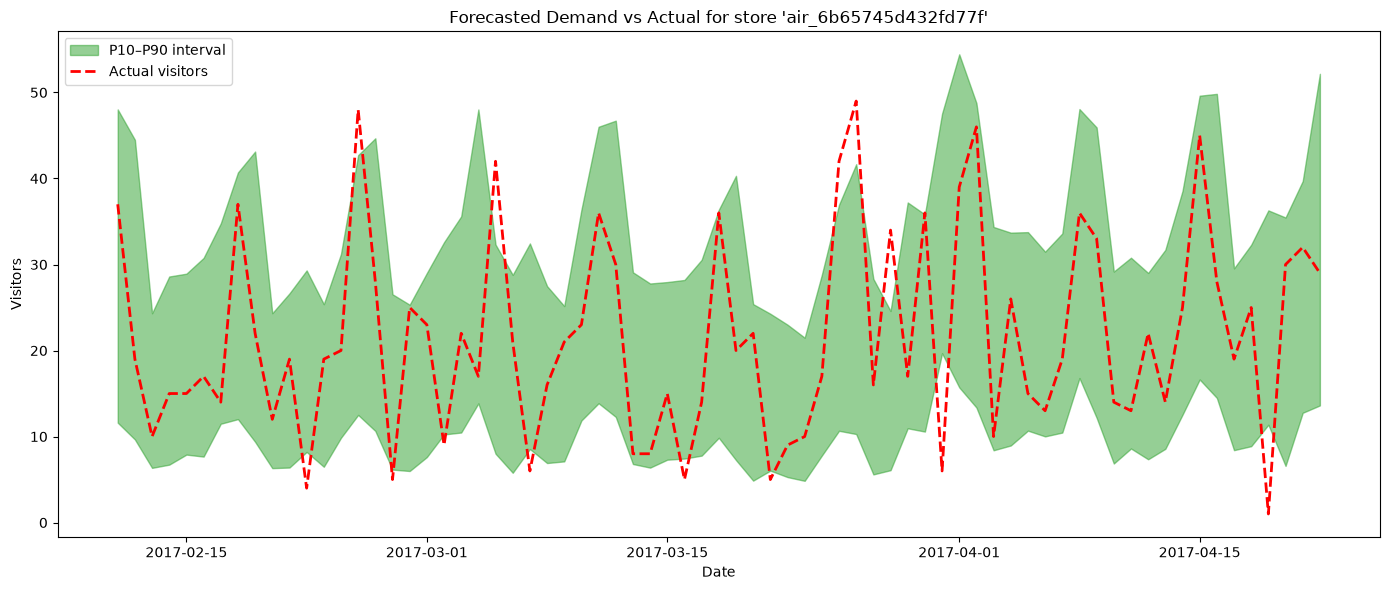

In [24]:
# Filter to the chosen restaurant, sort by date
store_data = viz[viz["store_id"] == chosen_store].sort_values("date")

plt.figure(figsize=(14, 6))

# Shaded P10-P90 band
plt.fill_between(store_data["date"], store_data["p10"], store_data["p90"],
                 alpha=0.50, color="tab:green", label="P10–P90 interval")

# Actual visitors
plt.plot(store_data["date"], store_data["actual"],
         color="red", linewidth=2, label="Actual visitors", linestyle="--")

plt.title(f"Forecasted Demand vs Actual for store '{chosen_store}'")
plt.xlabel("Date")
plt.ylabel("Visitors")
plt.legend()
plt.tight_layout()
plt.show()